In [ ]:
import torch
from huggingface_hub import hf_hub_download
from transformer_lens import HookedTransformer, HookedTransformerConfig, utils, ActivationCache
import numpy as np
import pandas as pd
import ast
from torch.utils.data import Dataset, DataLoader
import torch
from functools import partial
import circuitsvis as cv
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import plotly.express as px
import re
import einops
import plotly.graph_objects as go
from jaxtyping import Float, Int
from plotly.subplots import make_subplots
from torch import Tensor
from rich import print as rprint
from rich.table import Column, Table
from IPython.display import HTML, display
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Updates

Hypothesis: Layer 0 acts as a processor that writes two distinct types of information (E1, R and E2) into the residual stream at each comma's position. These two informations live in different subspaces of the 256-dim residual stream. 

If I understood it correctly, this would also explain also why Patrick observed that it seems like that E2 is repeatedly output at 4 positions after E2 - so it is already in the "right space" and just needs to be copied

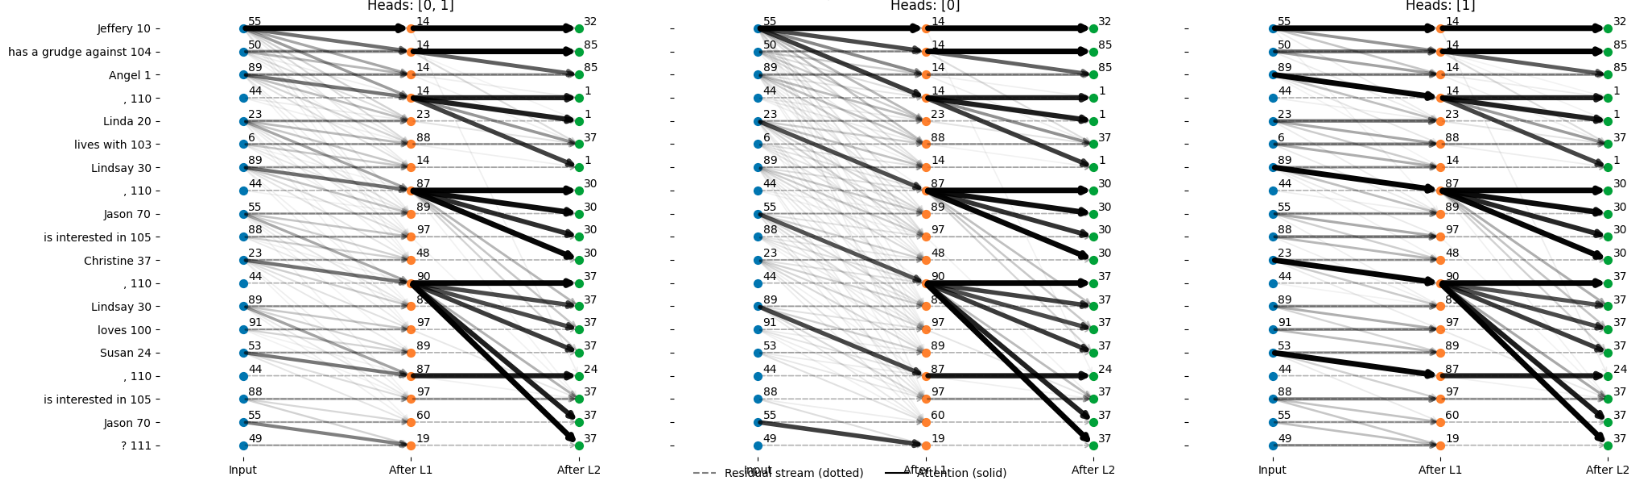

"Key" Subspace (created by L0H0): At each comma, Head L0H0 writes a vector that encodes the identity of the pair (E1, R)

"Value" Subspace (L0H1): At the same comma, L0H1 writes vector that encodes E2

# Setup 

In [ ]:
from huggingface_hub import hf_hub_download

REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

REPO_ID = "sojup/entity_binding_test"
FILENAME = "id_to_entity.csv"

id_mapping_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

E = 100
T = 10
D_VOCAB = E + T + 3
N_LAYERS = 2
HEADS = 2
d_model = 256
n_ctx   = 64

def build_model(n_layers: int, n_heads: int) -> HookedTransformer:
    if d_model % n_heads != 0:
        return None
    d_head = d_model // n_heads

    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)

model = build_model(N_LAYERS, HEADS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load the model
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)

print("Model loaded successfully.")

# need this for attention patching later
model.cfg.use_attn_result = True

id_mapping_df = pd.read_csv(id_mapping_path)
id_to_entity = dict(zip(id_mapping_df['id'], id_mapping_df['name']))

id_to_entity[100] = 'loves'
id_to_entity[101] = 'works with'
id_to_entity[102] = 'interacts with'
id_to_entity[103] = 'lives with'
id_to_entity[104] = 'has a grudge against'
id_to_entity[105] = 'is interested in'
id_to_entity[106] = 'plays with'
id_to_entity[107] = 'goes to school with'
id_to_entity[108] = 'is jealous of'
id_to_entity[109] = 'wants'

id_to_entity_rev = {v: k for k, v in id_to_entity.items()}

class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label  = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label

from datasets import load_dataset

dataset = load_dataset("sojup/entity_binding", split="test")

test_df = dataset.to_pandas()
test_dataset = EntityBindingDataset(test_df)

# Visualizing the Subspaces with PCA

In [ ]:
# Collect hook_z for both L0H0 and L0H1 - then label them as H0 and H1 - and plot

In [ ]:
def build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", marker_token=110):
    model.eval()
    X_rows = []
    y_rows = []

    with torch.no_grad():
        for i in tqdm(range(len(test_dataset))):
            tokens = test_dataset[i][0]
            _, cache = model.run_with_cache(tokens)

            acts = cache[hook_name]
            if acts.dim() >= 3:
                acts = acts.squeeze(0)

            # Find positions of the marker token
            pos_list = (tokens == marker_token).nonzero(as_tuple=False).squeeze(-1).tolist()
            if isinstance(pos_list, int):
                pos_list = [pos_list]

            # For each marker position, take activations from both heads
            for p in pos_list:
                if p <= 0:
                    continue
                X_rows.append(acts[p, 0, :].detach().cpu())
                y_rows.append(0)
                X_rows.append(acts[p, 1, :].detach().cpu())
                y_rows.append(1)

            del cache

    X = torch.stack(X_rows, dim=0) if X_rows else torch.empty(0)
    y = torch.tensor(y_rows, dtype=torch.long) if y_rows else torch.empty(0, dtype=torch.long)
    return X, y

In [ ]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z")

In [ ]:
def visualize_pca_subset(X, y, title="PCA (subset)", figsize=(7, 6)):
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    if isinstance(y, torch.Tensor):
        y_np = y.detach().cpu().numpy()
    else:
        y_np = np.asarray(y)


    X_std = StandardScaler().fit_transform(X_np)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_std)
    evr = pca.explained_variance_ratio_
    print(f"Explained variance ratio: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}")

    unique_classes = np.unique(y_np)
    cmap = get_cmap("tab10" if len(unique_classes) <= 10 else "tab20")
    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    colors = [cmap(class_to_idx[lab] % cmap.N) for lab in y_np]

    plt.figure(figsize=figsize)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=colors, alpha=0.8)
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.grid(True, linestyle="--", alpha=0.3)

    handles = []
    for c in unique_classes:
        idx = class_to_idx[c]
        label = f"{c} (n={np.sum(y_np == c)})"
        handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=cmap(idx % cmap.N), markersize=6, label=label))
    plt.legend(handles=handles, title="Classes")

    plt.tight_layout()
    plt.show()

visualize_pca_subset(X, y, title="PCA — L0H0 vs L0H1")

# Compositional Probing

Hypothesis: The vector that L0H0 writes for the fact (E1, T) is a linear combination of a vector direction for E1 and an orthogonal vector direction for T.


z(E1, T) = direction(E1) + direction(T)

In [ ]:
constructed = torch.tensor([1, 101, 50, 110, 1,  102, 49, 110, 2,  101, 73,  110, 2,  102, 65, 110, 101, 2, 111])

In [ ]:
[id_to_entity[i.item()] for i in constructed]

In [ ]:
logits, cache = model.run_with_cache(constructed)

In [ ]:
probs = torch.softmax(logits[0, -1, :], dim=-1)

for i, idx2 in enumerate(torch.topk(probs, 2).indices.tolist()):
  print(f"{id_to_entity[idx2]} {torch.topk(probs, 2).values.tolist()[i]}")

In [ ]:
cache

In [ ]:
e1_r1_l0h0 = cache['blocks.0.attn.hook_z'][0,3,0,:]
e1_r2_l0h0 = cache['blocks.0.attn.hook_z'][0,7,0,:]
e2_r1_l0h0 = cache['blocks.0.attn.hook_z'][0,11,0,:]
e2_r2_l0h0 = cache['blocks.0.attn.hook_z'][0,15,0,:]

In [ ]:
diff1 = e1_r1_l0h0 - e2_r1_l0h0 # substracting out the relation

In [ ]:
diff2 = e1_r2_l0h0 - e2_r2_l0h0

In [ ]:
import torch.nn.functional as F
F.cosine_similarity(diff1, diff2, dim=0)

In [ ]:
# substracting out the entity

diff1 = e1_r1_l0h0 - e1_r2_l0h0
diff2 = e2_r1_l0h0 - e2_r2_l0h0
F.cosine_similarity(diff1, diff2, dim=0)

In [ ]:
from collections import defaultdict

@torch.no_grad()
def compute_l0_class_means(model, dataset, comma_token=110):
    model.eval()
    d_head = model.cfg.d_head

    sum_entity_addr   = torch.zeros((E, d_head), dtype=torch.float32, device="cpu")
    cnt_entity_addr   = torch.zeros(E, dtype=torch.long)
    sum_relation_addr = torch.zeros((T, d_head), dtype=torch.float32, device="cpu")
    cnt_relation_addr = torch.zeros(T, dtype=torch.long)
    sum_entity_cont   = torch.zeros((E, d_head), dtype=torch.float32, device="cpu")
    cnt_entity_cont   = torch.zeros(E, dtype=torch.long)

    glob_sum_addr     = torch.zeros(d_head, dtype=torch.float32, device="cpu")
    glob_cnt_addr     = 0
    glob_sum_cont     = torch.zeros(d_head, dtype=torch.float32, device="cpu")
    glob_cnt_cont     = 0

    hook = f"blocks.0.attn.hook_z"

    for i in tqdm(range(len(dataset))):
        tokens = dataset[i][0]
        logits, cache = model.run_with_cache(tokens)

        z = cache[hook].squeeze(0)

        comma_pos = (tokens == comma_token).nonzero(as_tuple=False).flatten().tolist()

        for p in comma_pos:
            E1_tok = int(tokens[p-3].item())
            T_tok  = int(tokens[p-2].item())
            E2_tok = int(tokens[p-1].item())

            z_addr = z[p, 0, :].detach() # L0H0 @ comma
            z_cont = z[p, 1, :].detach() # L0H1 @ comma

            rel_idx = T_tok - 100

            sum_entity_addr[E1_tok]   += z_addr; cnt_entity_addr[E1_tok]   += 1
            sum_relation_addr[rel_idx]+= z_addr; cnt_relation_addr[rel_idx]+= 1
            glob_sum_addr             += z_addr; glob_cnt_addr             += 1

            sum_entity_cont[E2_tok]   += z_cont; cnt_entity_cont[E2_tok]   += 1
            glob_sum_cont             += z_cont; glob_cnt_cont             += 1

        del cache

    entity_means_addr = sum_entity_addr / cnt_entity_addr[:, None]
    relation_means_addr = sum_relation_addr / cnt_relation_addr[:, None]
    entity_means_cont = sum_entity_cont / cnt_entity_cont[:, None]
    global_mean_addr = glob_sum_addr / glob_cnt_addr
    global_mean_cont = glob_sum_cont / glob_cnt_cont

    counts = {
        "entity_addr": cnt_entity_addr,
        "relation_addr": cnt_relation_addr,
        "entity_cont": cnt_entity_cont,
        "total_commas": glob_cnt_addr,
    }
    return (entity_means_addr, relation_means_addr, entity_means_cont,
            global_mean_addr, global_mean_cont, counts)


In [ ]:
entity_means_addr, relation_means_addr, entity_means_cont, global_mean_addr, global_mean_cont, counts = compute_l0_class_means(model, test_dataset)

In [ ]:
entity_means_addr.shape # l0h0

In [ ]:
entity_means_addr[1].shape # (E1, R1)

In [ ]:
counts

In [ ]:
entity_means_addr_centered = entity_means_addr - global_mean_addr[None, :]
relation_means_addr_centered = relation_means_addr - global_mean_addr[None, :]
entity_means_cont_centered = entity_means_cont - global_mean_cont[None, :]

In [ ]:
example, label = test_dataset[0]

In [ ]:
[id_to_entity[int(t)] for t in example]

In [ ]:
# Now what we want to do is replace the Layer0 Hook_z Head0 Activations of "Linda lives with" with the template "Jason is interested in"

In [ ]:
jason_tok = id_to_entity_rev["Jason"]
interested_tok = id_to_entity_rev["is interested in"]
addr_template = entity_means_addr[jason_tok] + relation_means_addr_centered[interested_tok-100]

In [ ]:
linda_tok = id_to_entity_rev["Linda"]
lives_with_tok = id_to_entity_rev["lives with"]
addr_template2 = entity_means_addr[linda_tok] + relation_means_addr_centered[lives_with_tok-100]

In [ ]:
entity_template = entity_means_cont[id_to_entity_rev["Christine"]]

In [ ]:
def hook_addr(z, hook):
    z[0, 7, 0, :] = addr_template # position 7 is the relevant comma!
    return z

In [ ]:
def hook_addr2(z, hook):
    z[0, 11, 0, :] = addr_template2 # position 11 is the relevant comma!
    return z

In [ ]:
logits.shape

In [ ]:
logits = model(example)
logits_clean_christine = logits[0, -1, id_to_entity_rev["Christine"]]
logits_clean_lindsay = logits[0, -1, id_to_entity_rev["Lindsay"]]
logits_clean_christine, logits_clean_lindsay

In [ ]:
probs = torch.softmax(logits[0, -1, :], dim=-1)
for i, idx2 in enumerate(torch.topk(probs, 2).indices.tolist()):
    print(f"{id_to_entity[idx2]} {torch.topk(probs, 2).values.tolist()[i]}")

In [ ]:
logits = model.run_with_hooks(example, fwd_hooks=[('blocks.0.attn.hook_z', hook_addr)])

In [ ]:
logits_addr_christine = logits[0, -1, id_to_entity_rev["Christine"]]
logits_addr_lindsay = logits[0, -1, id_to_entity_rev["Lindsay"]]
logits_addr_christine, logits_addr_lindsay

In [ ]:
probs = torch.softmax(logits[0, -1, :], dim=-1)
for i, idx2 in enumerate(torch.topk(probs, 2).indices.tolist()):
    print(f"{id_to_entity[idx2]} {torch.topk(probs, 2).values.tolist()[i]}")

In [ ]:
logits = model.run_with_hooks(example, fwd_hooks=[('blocks.0.attn.hook_z', hook_addr), ('blocks.0.attn.hook_z', hook_addr2)])

In [ ]:
logits_addr2_christine = logits[0, -1, id_to_entity_rev["Christine"]]
logits_addr2_lindsay = logits[0, -1, id_to_entity_rev["Lindsay"]]
logits_addr2_christine, logits_addr2_lindsay

In [ ]:
probs = torch.softmax(logits[0, -1, :], dim=-1)
for i, idx2 in enumerate(torch.topk(probs, 2).indices.tolist()):
    print(f"{id_to_entity[idx2]} {torch.topk(probs, 2).values.tolist()[i]}")

In [ ]:
def hook_addr3(z, hook):
    z[0, 7, 1, :] = entity_template # Forcing christine back in place! Through L0H1
    return z

In [ ]:
logits = model.run_with_hooks(example, fwd_hooks=[('blocks.0.attn.hook_z', hook_addr), ('blocks.0.attn.hook_z', hook_addr2), ('blocks.0.attn.hook_z', hook_addr3)])

In [ ]:
probs = torch.softmax(logits[0, -1, :], dim=-1)
for i, idx2 in enumerate(torch.topk(probs, 5).indices.tolist()):
    print(f"{id_to_entity[idx2]} {torch.topk(probs, 5).values.tolist()[i]}")

In [ ]:
diff1 = relation_means_addr[interested_tok-100] - relation_means_addr_centered[interested_tok-100]

In [ ]:
diff2 = entity_means_addr[jason_tok] - entity_means_addr_centered[jason_tok]

In [ ]:
diff1

In [ ]:
diff2

In [ ]:
diff1-diff2

- L0H0 looks compositional. As difference in means shows z(E1, T) = direction(E1) + direction(T) (cos≈0.96 across relation swaps and ≈0.97 across entity swaps).


-> actually looks like its z(E1, T) = b + direction(E1) + direction(T)

In [ ]:
### Doing it over the dataset

In [ ]:
import random
def causal_intervention_analysis(model, dataset, entity_means_addr, relation_means_addr_centered, comma_token=110, query_token=111):
    model.eval()
    clean_logit_diff = []
    logit_swings_part1 = []
    logit_swings_part2 = []

    for i in tqdm(range(len(dataset))):
        tokens, label = dataset[i]
        tokens = tokens.to(device)
        target_label = label.item()

        comma_positions = (tokens == comma_token).nonzero(as_tuple=False).flatten().tolist()
        # Identify Target and Distractor Facts
        query_pos = (tokens == query_token).nonzero(as_tuple=False).item()
        target_e1_tok = tokens[query_pos - 1].item()

        target_r_tok = tokens[query_pos - 2].item()

        facts_at_commas = {
            p: (tokens[p-3].item(), tokens[p-2].item(), tokens[p-1].item()) for p in comma_positions
        }

        target_comma_pos = next((pos for pos, fact in facts_at_commas.items() if fact[0] == target_e1_tok and fact[1] == target_r_tok), None)

        if not target_comma_pos:
            print("Bug!")

        other_comma_pos = [pos for pos in comma_positions if pos != target_comma_pos]

        if not other_comma_pos:
            print("Bug2")

        distractor_comma_pos = random.choice(other_comma_pos)
        distractor_e2_tok = facts_at_commas[distractor_comma_pos][2]

        # Create Canonical and Corrupt Address Vectors
        # Canonical address for the target fact (E1, R)
        target_address = (entity_means_addr[target_e1_tok] + relation_means_addr_centered[target_r_tok - 100]).to(device)

        # Corrupt address
        while True:
            corrupt_e1 = random.randint(0, E-1)
            corrupt_r = random.randint(100, 100+T-1)
            if corrupt_e1 != target_e1_tok and corrupt_r != target_r_tok:
                break
        corrupt_address = (entity_means_addr[corrupt_e1] + relation_means_addr_centered[corrupt_r - 100]).to(device)

        def hook_replace_distractor_addr(z, hook):
            # Patch the target address into the distractor comma's position
            z[0, distractor_comma_pos, 0, :] = target_address
            return z

        def hook_corrupt_target_addr(z, hook):
            # Patch a corrupt address into the original target comma's position
            z[0, target_comma_pos, 0, :] = corrupt_address
            return z

        # Clean run
        clean_logits = model(tokens)[0, -1, :]

        # Patch target address into distractor position
        hooked_logits_part1 = model.run_with_hooks(
            tokens,
            fwd_hooks=[('blocks.0.attn.hook_z', hook_replace_distractor_addr)]
        )[0, -1, :]

        # Patch target to distractor AND corrupt original target
        hooked_logits_part2 = model.run_with_hooks(
            tokens,
            fwd_hooks=[
                ('blocks.0.attn.hook_z', hook_replace_distractor_addr),
                ('blocks.0.attn.hook_z', hook_corrupt_target_addr)
            ]
        )[0, -1, :]

        # Clean Logits
        clean = clean_logits[distractor_e2_tok].item() - clean_logits[target_label].item()
        clean_logit_diff.append(clean)

        # How much did the prediction swing from the correct to the distractor's E2?
        swing1 = hooked_logits_part1[distractor_e2_tok].item() - hooked_logits_part1[target_label].item()
        logit_swings_part1.append(swing1)

        # How much did it swing when we also corrupted the original location?
        swing2 = hooked_logits_part2[distractor_e2_tok].item() - hooked_logits_part2[target_label].item()
        logit_swings_part2.append(swing2)

    avg_clean = np.mean(clean_logit_diff)
    avg_swing1 = np.mean(logit_swings_part1)
    avg_swing2 = np.mean(logit_swings_part2)

    print(f"Baseline Logit diff: {avg_clean}")
    print(f"Experiment 1 (Address Relocation):") # Essentially means the same adress information is at 2 different comma positions
    print(f"  Average Logit Swing (logit(E2') - logit(E2)): {avg_swing1}")
    print(f"Experiment 2 (Relocation + Original Address Ablation):") # Changing the adress information at the ORIGINAL correct comma position
    print(f"  Average Logit Swing (logit(E2') - logit(E2)): {avg_swing2}")

    return clean_logit_diff, logit_swings_part1, logit_swings_part2

clean_logit_diff, logit_swings_part1, logit_swings_part2 = causal_intervention_analysis(model, test_dataset, entity_means_addr, relation_means_addr_centered)

In [ ]:
patched_margin_part2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reconstruct actual margins
clean_margin = records_df["clean_margin"]
patched_margin_part1 = records_df["part1_margin"] # This should be clean_margin + logit_swings_part1
patched_margin_part2 = records_df["part2_margin"] # This should be clean_margin + logit_swings_part2

datasets = [
    clean_margin,
    patched_margin_part1,
    patched_margin_part2,
]

labels = [
    "Clean",
    "Patch distractor address",
    "Patch distractor + corrupt original",
]

means = [np.mean(d) for d in datasets]

# Shared bins so the three panels are comparable
xmin = min(d.min() for d in datasets)
xmax = max(d.max() for d in datasets)
bin_edges = np.linspace(xmin, xmax, 28)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, constrained_layout=True)

colors = ["#4c78a8", "#f58518", "#e45756"]

for ax, data, label, mean_val, color in zip(axes, datasets, labels, means, colors):
    counts, _ = np.histogram(data, bins=bin_edges)
    ax.bar(
        bin_edges[:-1],
        counts,
        width=np.diff(bin_edges),
        edgecolor="black",
        linewidth=0.6,
        align="edge",
        color=color,
        alpha=0.85,
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(mean_val, color="crimson", linewidth=1.5)

    ax.set_title(label, fontsize=12)
    ax.set_xlabel("logit(distractor) - logit(correct)")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.2)

    ax.text(
        0.04,
        0.92,
        f"mean = {mean_val:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="none"),
    )

fig.suptitle("Causal interventions on the address representation", fontsize=14)
plt.savefig("causal_intervention_results.png", dpi=300)
plt.show()


In [ ]:
datasets = [clean_logit_diff, logit_swings_part1, logit_swings_part2]
labels = ["Clean", "Patch DISTRACTOR Address", "ALSO Patch CORRECT Address"]

num_bins = 20
bin_edges = np.linspace(min(min(d) for d in datasets),
                        max(max(d) for d in datasets),
                        num_bins + 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, data, label in zip(axes, datasets, labels):
    counts, _ = np.histogram(data, bins=bin_edges)
    ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
           edgecolor="black", align="edge")
    ax.set_title(label)
    ax.set_xlabel("Bins")
    ax.set_ylabel("Counts")

fig.suptitle("-", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
def vector_orthogonality(entity_means_addr_centered, relation_means_addr_centered, entity_means_cont_centered):
    """
    Calculates and prints the average absolute cosine similarity between and within
    the *centered* canonical vector spaces for E1, T, and E2.
    """
    e1_vecs = F.normalize(entity_means_addr_centered.float().cpu(), p=2, dim=1)
    t_vecs = F.normalize(relation_means_addr_centered.float().cpu(), p=2, dim=1)
    e2_vecs = F.normalize(entity_means_cont_centered.float().cpu(), p=2, dim=1)

    cos_sim_e1_t = torch.abs(e1_vecs @ t_vecs.T)
    avg_cos_sim_e1_t = cos_sim_e1_t.mean().item()

    cos_sim_e1_e2 = torch.abs(e1_vecs @ e2_vecs.T)
    avg_cos_sim_e1_e2 = cos_sim_e1_e2.mean().item()

    cos_sim_t_e2 = torch.abs(t_vecs @ e2_vecs.T)
    avg_cos_sim_t_e2 = cos_sim_t_e2.mean().item()

    cos_sim_e1_e1 = torch.abs(e1_vecs @ e1_vecs.T)
    cos_sim_e1_e1.fill_diagonal_(0) # excluding self-similarity
    avg_cos_sim_e1_e1 = cos_sim_e1_e1.sum().item() / (e1_vecs.shape[0] * (e1_vecs.shape[0] - 1))

    cos_sim_t_t = torch.abs(t_vecs @ t_vecs.T)
    cos_sim_t_t.fill_diagonal_(0)
    avg_cos_sim_t_t = cos_sim_t_t.sum().item() / (t_vecs.shape[0] * (t_vecs.shape[0] - 1))

    cos_sim_e2_e2 = torch.abs(e2_vecs @ e2_vecs.T)
    cos_sim_e2_e2.fill_diagonal_(0)
    avg_cos_sim_e2_e2 = cos_sim_e2_e2.sum().item() / (e2_vecs.shape[0] * (e2_vecs.shape[0] - 1))

    print("Between-Space Cosine Sim")
    print(f"  E1 ('Key' Entity) vs T ('Key' Relation): {avg_cos_sim_e1_t}")
    print(f"  E1 ('Key' Entity) vs E2 ('Value' Entity): {avg_cos_sim_e1_e2}")
    print(f"  T ('Key' Relation) vs E2 ('Value' Entity): {avg_cos_sim_t_e2}")
    print("Within-Space Cosine Sim")
    print(f"  E1 vs E1 (different entities): {avg_cos_sim_e1_e1}")
    print(f"  T vs T (different relations):  {avg_cos_sim_t_t}")
    print(f"  E2 vs E2 (different entities): {avg_cos_sim_e2_e2}")

vector_orthogonality(entity_means_addr_centered, relation_means_addr_centered, entity_means_cont_centered)

In [ ]:
# E1 and T to E2 are near 0 -> almost orthogonal. Within-Cosine sim not as high as expected, but in same ballpark as E1 to T
# -> E1 and T are not computed independently, but composed

In [ ]:
import random
import pandas as pd
from tqdm import tqdm


@torch.no_grad()
def collect_causal_intervention_records(
    model,
    dataset,
    entity_means_addr,
    relation_means_addr_centered,
    comma_token=110,
    query_token=111,
    seed=0,
):
    random.seed(seed)
    model.eval()
    rows = []

    for i in tqdm(range(len(dataset))):
        tokens, label = dataset[i]
        tokens = tokens.to(device)
        target_label = int(label.item())

        comma_positions = (tokens == comma_token).nonzero(as_tuple=False).flatten().tolist()
        query_pos = (tokens == query_token).nonzero(as_tuple=False).item()

        target_e1_tok = int(tokens[query_pos - 1].item())
        target_r_tok = int(tokens[query_pos - 2].item())

        facts_at_commas = {
            p: (
                int(tokens[p - 3].item()),
                int(tokens[p - 2].item()),
                int(tokens[p - 1].item()),
            )
            for p in comma_positions
        }

        target_comma_pos = next(
            (
                pos
                for pos, fact in facts_at_commas.items()
                if fact[0] == target_e1_tok and fact[1] == target_r_tok
            ),
            None,
        )
        if target_comma_pos is None:
            continue

        other_comma_pos = [
            pos for pos in comma_positions
            if pos != target_comma_pos and facts_at_commas[pos][2] != target_label
        ]

        if not other_comma_pos:
            continue

        distractor_comma_pos = random.choice(other_comma_pos)
        distractor_fact = facts_at_commas[distractor_comma_pos]
        distractor_e2_tok = distractor_fact[2]

        target_fact = facts_at_commas[target_comma_pos]

        target_address = (
            entity_means_addr[target_e1_tok] + relation_means_addr_centered[target_r_tok - 100]
        ).to(device)

        while True:
            corrupt_e1 = random.randint(0, E - 1)
            corrupt_r = random.randint(100, 100 + T - 1)
            if corrupt_e1 != target_e1_tok and corrupt_r != target_r_tok:
                break

        corrupt_address = (
            entity_means_addr[corrupt_e1] + relation_means_addr_centered[corrupt_r - 100]
        ).to(device)

        def hook_replace_distractor_addr(z, hook):
            z[0, distractor_comma_pos, 0, :] = target_address
            return z

        def hook_corrupt_target_addr(z, hook):
            z[0, target_comma_pos, 0, :] = corrupt_address
            return z

        clean_logits = model(tokens.unsqueeze(0))[0, -1, :]

        logits_part1 = model.run_with_hooks(
            tokens.unsqueeze(0),
            fwd_hooks=[("blocks.0.attn.hook_z", hook_replace_distractor_addr)],
        )[0, -1, :]

        logits_part2 = model.run_with_hooks(
            tokens.unsqueeze(0),
            fwd_hooks=[
                ("blocks.0.attn.hook_z", hook_replace_distractor_addr),
                ("blocks.0.attn.hook_z", hook_corrupt_target_addr),
            ],
        )[0, -1, :]

        clean_margin = clean_logits[distractor_e2_tok].item() - clean_logits[target_label].item()
        part1_margin = logits_part1[distractor_e2_tok].item() - logits_part1[target_label].item()
        part2_margin = logits_part2[distractor_e2_tok].item() - logits_part2[target_label].item()

        rows.append(
            {
                "dataset_idx": i,
                "target_comma_pos": target_comma_pos,
                "distractor_comma_pos": distractor_comma_pos,
                "target_fact": target_fact,
                "distractor_fact": distractor_fact,
                "clean_margin": clean_margin,
                "part1_margin": part1_margin,
                "part2_margin": part2_margin,
                "part1_swing": part1_margin - clean_margin,
                "part2_swing": part2_margin - clean_margin,
            }
        )

    return pd.DataFrame(rows)


In [ ]:
records_df = collect_causal_intervention_records(
    model,
    test_dataset,
    entity_means_addr,
    relation_means_addr_centered,
    seed=0,
)

records_df.head()


In [ ]:
records_df.sort_values("part2_margin").head(10)


In [ ]:
def show_example_from_record(row):
    dataset_idx = int(row["dataset_idx"])
    tokens, label = test_dataset[dataset_idx]

    print("dataset_idx:", dataset_idx)
    print("clean_margin:", row["clean_margin"])
    print("part1_margin:", row["part1_margin"])
    print("part2_margin:", row["part2_margin"])
    print("target_fact:", tuple(id_to_entity[x] for x in row["target_fact"]))
    print("distractor_fact:", tuple(id_to_entity[x] for x in row["distractor_fact"]))
    print()

    for pos, tok in enumerate(tokens.tolist()):
        name = id_to_entity[int(tok)]
        mark = ""
        if pos == row["target_comma_pos"]:
            mark = "  <-- target comma"
        elif pos == row["distractor_comma_pos"]:
            mark = "  <-- distractor comma"
        print(pos, name, mark)


In [ ]:
show_example_from_record(records_df.sort_values("part2_margin").iloc[0])
